<div style='text-align: right; font-size: 16px;'>
<br/>
<img src="images/HWR_logo.svg" alt="drawing" width="30%"/>
<br/>
Fachbereich Duales Studium Wirtschaft • Technik<br/>
ET1031 Mathematische Grundlagen III (Signale und Systeme)<br/>
Prof. Dr. Luis Fernando Ferreira Furtado, Berlin, 17.08.2026<br/>
</div>

# Kapitel 2. Mathematische Grundlagen

<hr style="border:solid #000000 1px;height:1px;">

In [44]:
import numpy as np
import sympy as sp
import math
import matplotlib.pyplot as plt
from IPython.display import display, Latex
from ipywidgets import interact, FloatSlider

def cartesian2polar(z):
    """
    ------------------------------------------------------------------------------------------------------------
    This function converts a complex number from the cartesian form to the polar form

    Parameter:
        z: a complex number in the cartesian form

    Returns:
        radius: a float with the absolute value of the complex number z
        angle: a float with the angle (in radians) of the complex number z
    ------------------------------------------------------------------------- Dr.Furtado, Berlin, 22.08.2025 ---
    """    

    radius = abs(z)
    angle = np.angle(z)

    return radius, angle
    

def polar2cartesian(radius, angle):
    """
    ------------------------------------------------------------------------------------------------------------
    This function converts a complex number from the polar form to the cartesian form

    Parameter:
        radius: a float with the absolute value of the complex number z

    Return:
        z: a complex number in the cartesian form
    ------------------------------------------------------------------------- Dr.Furtado, Berlin, 22.08.2025 ---
    """      

    real = np.cos(angle) * radius
    imaginary = np.sin(angle) * radius
    z = complex(real, imaginary)

    return z


def plot_complex(**z):
    """
    ------------------------------------------------------------------------------------------------------------
    This function converts a complex number from the polar form to the cartesian form

    Parameters:
        z*: a complex number (or more complex numbers) to be plotted
    ------------------------------------------------------------------------- Dr.Furtado, Berlin, 22.08.2025 ---
    """      

    # Check if dict
    for z_ in z:
        if type(z[z_])==dict:
            z = z[z_]
        break

    # Set the figure
    fig, ax = plt.subplots(1)

    # Define and plot the unity circle
    theta = np.linspace(0, 2*np.pi, 100)
    x = np.cos(theta)
    y = np.sin(theta)
    ax.plot(x, y, 'grey', linestyle=':', alpha=0.5)

    # Get the maximal (x or y) value of all complex numbers
    limit = []
    for z_ in z:
        limit.append(abs(z[z_]))
    limit = max(limit)
    if limit < 1: limit = 1
    limit = math.ceil(1.1 * limit)

    # Plot the complex numbers
    n = 0
    for z_ in z:
        label = f"${z[z_]:.2f}$".replace("j", r"\mathrm{j}")
        #label = '$' + z_ + ' = {0:.2f} {1} {2:.2f}j'.format(z[z_].real, '+-'[z[z_].imag < 0], abs(z[z_].imag)) + '$'
        ax.arrow(0, 0, z[z_].real, z[z_].imag, label=label, length_includes_head=True,\
            head_width=limit/20, head_length=limit/20, fc=plt.get_cmap('Set1').colors[n], ec=plt.get_cmap('Set1').colors[n])
        ax.annotate('$' +z_ + '$', (z[z_].real + limit/100, z[z_].imag + limit/100,) , fontsize=11)
        if n>=8: 
            n=0
        else: 
            n+=1
    
    # Configure the plot aesthetics
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), prop=dict(size=9))
    ax.set_xlabel('Reale') 
    ax.set_ylabel('Imaginäre')
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    line_kwargs = {"color": "black", "lw":0.5, "alpha": 0.5}
    ax.axhline(0, **line_kwargs)
    ax.axvline(0, **line_kwargs)
    ax.set_aspect(1)
    ax.set_axisbelow(True)
    plt.grid(linestyle=':', color='grey', alpha=0.5)    
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.gcf().set_dpi(150)
    #plt.style.use('dark_background')

    #plt.gca().set_position([-0.05, 0.1, 0.9, 0.8])
    #plt.savefig("fig.svg", format="svg")
    # Show the figure
    plt.show()

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.1
__Lineare Gleichung__
<br/>
Finden die Frequenz $𝑓_𝑜$ und die Konstante $\mu$ für die folgende Gleichung: $$f(t) = 2\mu t + f_0$$<br/>
<br/>
Wenn $𝑡 = 0$ s, dann $f(𝑡) = 200$ Hz.<br/>
Wenn $𝑡 = 10$ s, dann $f(𝑡) = 3500$ Hz.<br/>

In [45]:
t = [0, 10]
y = [200, 3500]

mu, f_0 = np.polyfit(t,y,1)
mu = round(mu/2)
f_0 = round(f_0)

display(Latex('$f(t)=2(' + str(mu) + ')t + '+ str(f_0) +' $'))

<IPython.core.display.Latex object>

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.2
__Infinitesimalrechnung__
<br/>
Berechnen Sie die Ableitung der folgenden Funktionen:
<br/><br/>
a) $x(t)=e^{-2t}+cos(\omega t)$
<br/><br/>
b) $x(t)=e^{-2t}sin(\omega t)$
<br/><br/>
c) $x(t)=tan(\omega t)$

In [46]:
t, omega = sp.symbols('t omega')

# a) 
x = sp.exp(-2*t) + sp.cos(omega*t)
display(sp.diff(x, t))

# b) 
x = sp.exp(-omega*t) * sp.sin(omega*t)
display(sp.diff(x, t))

# c) 
x = sp.tan(omega*t)
display(sp.diff(x, t))

-omega*sin(omega*t) - 2*exp(-2*t)

-omega*exp(-omega*t)*sin(omega*t) + omega*exp(-omega*t)*cos(omega*t)

omega*(tan(omega*t)**2 + 1)

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.3
__Infinitesimalrechnung__
<br/>
Berechnen Sie das folgende Integral:
<br/>
<br/>
$$\int_{0}^{4} te^{-5t} \,dt $$


In [47]:
t = sp.symbols('t')

display(sp.integrate(t * sp.exp(-5*t), (t, 0, 4)))

1/25 - 21*exp(-20)/25

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.4
__Infinitesimalrechnung__
<br/>
Summieren Sie die folgende geometrische Reihe:
<br/>
<br/>
$$10 \sum_{n=5}^{\infty} (1/2)^{n}$$


In [48]:
n = sp.symbols('n')

x = 10 * sp.summation((1/2)**n, (n, 5, sp.oo))

display(x)

0.625000000000000

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.5
__Komplexe Zahlen__
<br/>
Bestimmen Sie die Polarform der folgenden komplexen Zahlen in kartesischer Form:
<br/>
<br/>
a) $z_a = 1 + 4\mathrm{j}$<br/>
b) $z_b = -2 + 3\mathrm{j}$<br/>
c) $z_c = 3 - 2\mathrm{j}$<br/>
d) $z_d = -4 -1\mathrm{j}$<br/>
<br/>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

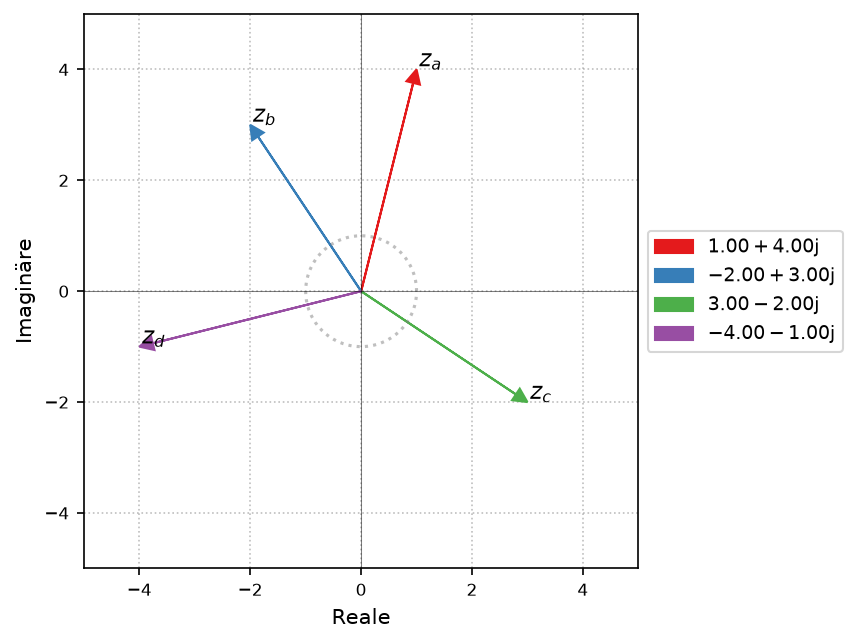

In [54]:
# Set the input data in cartesian form
z_a = 1 + 4j
z_b = -2 + 3j
z_c = 3 - 2j
z_d = -4 - 1j

# Display the convertion in the polar form
display(Latex(f"$z_a = {cartesian2polar(z_a)[0]:.2f}e^{{\\mathrm{{j}}{cartesian2polar(z_a)[1]:.2f}}}$"))
display(Latex(f"$z_b = {cartesian2polar(z_b)[0]:.2f}e^{{\\mathrm{{j}}{cartesian2polar(z_b)[1]:.2f}}}$"))
display(Latex(f"$z_c = {cartesian2polar(z_c)[0]:.2f}e^{{\\mathrm{{j}}{cartesian2polar(z_c)[1]:.2f}}}$"))
display(Latex(f"$z_d = {cartesian2polar(z_d)[0]:.2f}e^{{\\mathrm{{j}}{cartesian2polar(z_d)[1]:.2f}}}$"))

# Plot the graphic
plot_complex(z_a=z_a, z_b=z_b, z_c=z_c, z_d=z_d)

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.6
__Komplexe Zahlen__
<br/>
Bestimmen Sie die kartesische Form der folgenden komplexen Zahlen in der Polarform:
<br/>
<br/>
a) $z_a = 2e^{\mathrm{j}( \pi /3)}$<br/>
b) $z_b = 3e^{\mathrm{j}(- \pi /2)}$<br/>
c) $z_c = 4e^{\mathrm{j} \pi}$<br/>
d) $z_d = 5e^{-\mathrm{j}}$<br/>
<br/>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

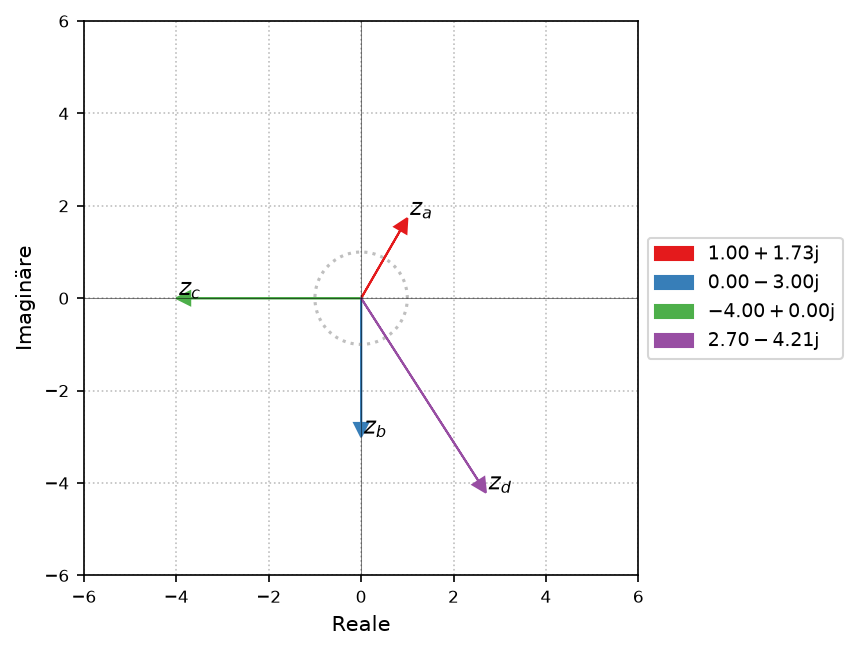

In [55]:
# Convert the input data in the cartesian form
z_a = polar2cartesian(2, np.pi/3)
z_b = polar2cartesian(3, -np.pi/2)
z_c = polar2cartesian(4, np.pi)
z_d = polar2cartesian(5, -1)


# Display the convertion in the cartesian form
display(Latex(f"$z_a = {z_a:.2f}$".replace("j", r"\mathrm{j}")))
display(Latex(f"$z_b = {z_b:.2f}$".replace("j", r"\mathrm{j}")))
display(Latex(f"$z_c = {z_c:.2f}$".replace("j", r"\mathrm{j}")))
display(Latex(f"$z_d = {z_d:.2f}$".replace("j", r"\mathrm{j}")))

# Plot the graphic
plot_complex(z_a=z_a, z_b=z_b, z_c=z_c, z_d=z_d)

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.7
__Komplexe Zahlen__
<br/>
Betrachte die beiden komplexen Zahlen $z_1$ und $z_2$. Dann berechnen und zeichnen Sie $z=z_1 z_2$ in den folgenden Fällen:
<br/>
<br/>
a) $z_1 = 2 + \mathrm{j}$ und $z_2 = 0.5$<br/>
b) $z_1 = 2 + \mathrm{j}$ und $z_2 = \mathrm{j}$<br/>
c) $z_1 = 2 + \mathrm{j}$ und $z_2 = 0.5\mathrm{j}$<br/>
<br/>

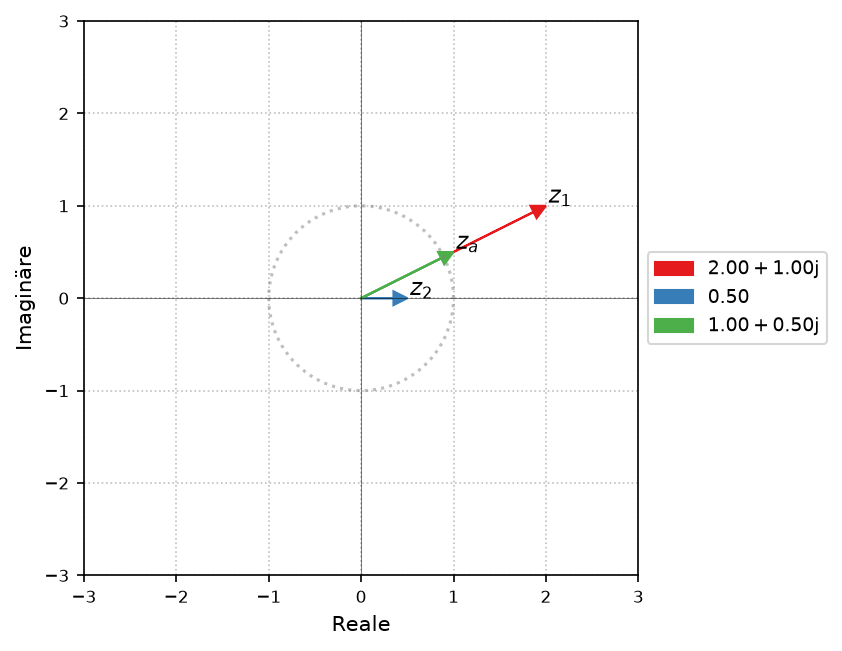

In [50]:
# a)
z_1 = 2 + 1j
z_2 = 0.5
z_a = z_1 * z_2

plot_complex(z_1=z_1, z_2=z_2, z_a=z_a)

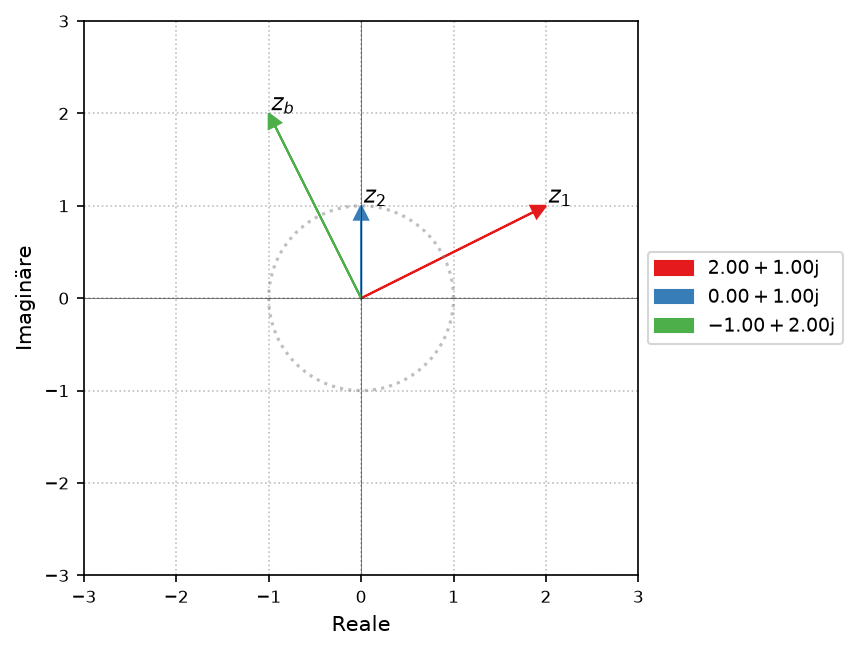

In [51]:
# b)
z_1 = 2 + 1j
z_2 = 1j
z_b = z_1 * z_2

plot_complex(z_1=z_1, z_2=z_2, z_b=z_b)

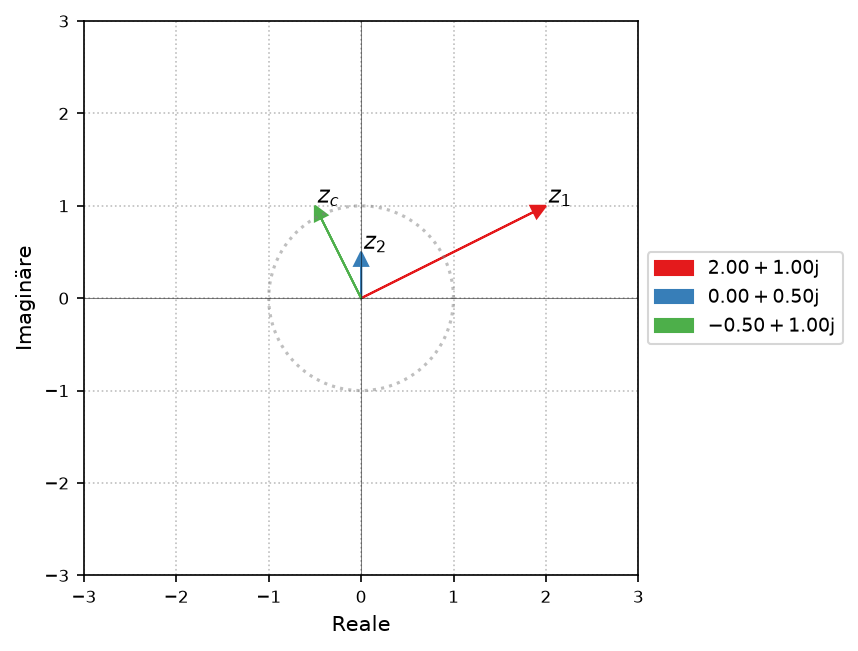

In [52]:
# c)
z_1 = 2 + 1j
z_2 = 0.5j
z_c = z_1 * z_2

plot_complex(z_1=z_1, z_2=z_2, z_c=z_c)

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.8
__Trigonometrie__
<br/>
Wenn man $\theta = - \pi / 2$ setzt und trigonometrische Identitäten berücksichtigt, wie könnte Gleichung $x(t) = \hat{x}cos(2 \pi ft - \theta)$ umgeschrieben werden?

<br/>

In [53]:
display(Latex(r'$x(t) = \hat {x}sin(2 \pi ft)$'))

<IPython.core.display.Latex object>

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.9
__Komplexen Zahlen__
<br/>
Zwei Signale $𝑥_1(𝑡)=4cos\left(𝜔t+\frac{𝜋}{4}\right)$ und $𝑥_2(𝑡)=6sin(𝜔t)$ haben die gleiche Winkelfrequenz $𝜔$.<br/>
Finden Sie das Summensignal $y(t) = x_1(t) + x_2(t)$ in der form $y(t)=Acos(𝜔𝑡+𝜙)$.<br/>

In [61]:
x_1 = polar2cartesian(4,np.pi/4)
x_2 = polar2cartesian(6,-np.pi/2)
x = x_1 + x_2

display(Latex(f"$x_1 = {x_1:.2f} = {cartesian2polar(x_1)[0]:.{2}f}e^{{j({cartesian2polar(x_1)[1]:.{3}f})}}$".replace("j", r"\mathrm{j}")))
display(Latex(f"$x_2 = {x_2:.2f} = {cartesian2polar(x_2)[0]:.{2}f}e^{{j({cartesian2polar(x_2)[1]:.{3}f})}}$".replace("j", r"\mathrm{j}")))
display(Latex(f"$x = {x:.2f} = {cartesian2polar(x)[0]:.{2}f}e^{{j({cartesian2polar(x)[1]:.{3}f})}}$".replace("j", r"\mathrm{j}")))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<hr style="border:solid #000000 1px;height:1px;">

#### Beispiel 2.10
__Partialbruchzerlegung__
<br/>
Betrachten Sie die Variable $x$ als reelle Zahl und bestimmen Sie die Partialbruchzerlegung für die folgenden Gleichungen: <br/><br/>
**a)** <font color="#CF232C">$f(x) = \dfrac{5x-9}{x^2-5x-6}$</font><br/><br/>
**b)** <font color="#CF232C">$f(x) = \dfrac{2x+1}{x^3+x^2+2x+2}$</font> <br/><br/>

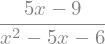

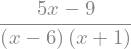

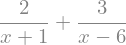

In [62]:
# a)
x= sp.symbols('x')
sp.init_printing(use_unicode=True)

# Ausdruck
expression = (5*x - 9) / (x**2 -5*x -6)

# Den Ausdruck anzeigen
display(expression)

# Faktorisierung des Nenners
display(sp.factor(expression))

# Zerlegung
display(sp.apart(expression))

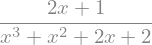

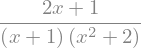

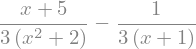

In [63]:
# b)
x= sp.symbols('x')
sp.init_printing(use_unicode=True)

# Ausdruck
expression = (2*x+1) / (x**3 + x**2 + 2*x + 2)

# Den Ausdruck anzeigen
display(expression)

# Faktorisierung des Nenners
display(sp.factor(expression))

# Zerlegung
display(sp.apart(expression))

<hr style="border:solid #000000 1px;height:1px;">
<strong>exp(x) Spiele</strong><br/>

In [64]:
def update(x):
    z = x**(1j*2*np.pi)
    plot_complex(z=z)

x = FloatSlider(min=1.0, max=4.0, value=1.0, step=0.01, description='x')
interact(update, x=x)

interactive(children=(FloatSlider(value=1.0, description='x', max=4.0, min=1.0, step=0.01), Output()), _dom_cl…

<function __main__.update(x)>

In [65]:
np.exp(1)

In [66]:
np.exp(np.log(2))